In [ ]:
"""
This file is about Maximum Likelihood

Based on Prof. Wu Lecture below:
https://www.youtube.com/watch?v=tKniDS6GDns&list=PLdk2fd27CQzQCoOj0YfBd4ECr76EqEXz4&index=18

"""

In [ ]:
""" Some conditional Probability Review:

p(x|y) = p(x n y) / p(y) : This means Probability of x given y = p(x and y) / p(y)

If independent the following hold:
p(x|y) = p(x)
p(x n y) = p(x)*p(y)

IID = Independent, Identically Distributed 
(This means all values in a dataset are independent but follow the same distribution)

"""

In [2]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

Guessed mean: 31.555737373492473, Guessed sigma: 3.0997240145486997
Actual mean: 31.840554068375404, Actual sigma: 3.1622576586223827


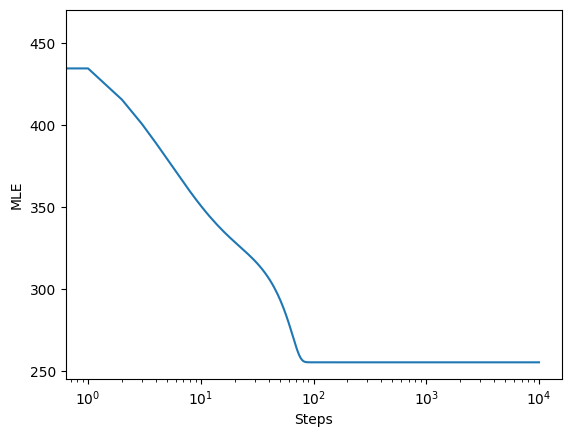

In [10]:
# Gradient Descent + MLE to identify mean and var for a normally distrubted dataset


# Generate random normally distributed data
secret_mean = random.uniform(0, 100)
secret_sigma = random.uniform(1, 20)
n = 100
random_numbers = np.random.normal(loc=secret_mean, scale=secret_sigma, size=n)

def gauss_prob(mean, sigma, data_point):
    return 1/(np.sqrt(2 * np.pi * sigma **2)) * np.exp(-((data_point - mean)**2 / (2*sigma**2)))

def gauss_mle(mean, sigma, data):
    return -np.sum(np.log(gauss_prob(mean, sigma, data)))

def mean_gradient(mean, sigma, data): # Partial Derivative of MLE with respect to mean
       return -np.sum(data - mean) / (sigma**2)

def sigma_gradient(mean, sigma, data): # Partial Derivative of MLE with respect to sigma
    n = len(data)
    return (n / sigma) - (np.sum((data - mean)**2) / (sigma**3))


def find_mean_sigma(mean_guess, sigma_guess, data, steps=100, mean_eta=0.1, sigma_eta=0.01):
    mle_tracker = []

    mean = mean_guess
    sigma = sigma_guess

    for i in range(steps):
        mean_grad = mean_gradient(mean, sigma, data)
        sigma_grad = sigma_gradient(mean, sigma, data)

        mean = mean - mean_eta * mean_grad # Gradient Descent of mean
        sigma = sigma - sigma_eta * sigma_grad # Gradient Descent of sigma

        mle = gauss_mle(mean, sigma, data)
        mle_tracker.append(mle)

    plt.plot(mle_tracker) # Seeing how MLE converges to the actual mean and sigma
    plt.xscale('log')
    plt.xlabel('Steps')
    plt.ylabel('MLE') 

    return mean, sigma
        
mean, sigma = find_mean_sigma(50, 10, random_numbers, steps=10000)

print(f"Guessed mean: {mean}, Guessed sigma: {sigma}")
print(f"Actual mean: {secret_mean}, Actual sigma: {secret_sigma}")


In [ ]:
"""
Part 2 of the lecture below
"""